#**DATA QUALITY**

**DATA QUALITY**

1. Data Completeness
Are there missing values in key columns (e.g., element concentrations, sample IDs)?

Are there any rows with mostly missing or empty data?

Are the total counts for numeric and object columns as expected?

2. Data Consistency

Are the sample IDs (SAMPLE column) unique and consistent in format?

Are all numeric values in concentration columns formatted correctly (e.g., no < or > remaining)?

Are duplicate entries present, and if so, do they represent valid replicates or errors?

3. Data Validity

Do element concentrations fall within expected ranges for the analyzed samples?

Are any outliers or anomalies evident in numeric data, such as extreme values?

Is there evidence of contamination or systematic errors in certain elements (e.g., unusually high/low values)?

4. Data Integrity

Are there redundant or conflicting columns, such as "Ca" and "Ca.1"? If so, are they properly documented?

Are all required columns present, and are their data types appropriate (e.g., float for concentrations, object for identifiers)?

5. Data Transformation Issues
Are all < and > characters removed from object-type columns?

Have numeric columns been successfully converted to numeric types where appropriate?

Are column names clean and consistent (e.g., no extra periods, numbers, or special characters)?

6. Statistical Analysis Preparation

Do the columns with element concentrations have enough non-null values for meaningful analysis?

Are any columns highly correlated or redundant, and could they be merged or excluded?

Are the concentrations normalized to appropriate reference values or standards?

7. Metadata and Units

Are the units of measurement clear and consistent across all columns?

Is there metadata indicating how data below the detection limit (<DL) was treated (e.g., replaced with zero or half of DL)?

Are derived columns, like "Ca.1," properly documented in terms of their calculation?

8. Quality Control and Replicates

Are there any replicates, and if so, do they show consistent results?

Are there blank or quality control (QC) samples in the dataset, and are they properly flagged?

Are QC values within acceptable ranges for precision and accuracy?

9. Anomalies and Outliers

Do histograms or boxplots for numeric columns reveal significant outliers?

Are there unexpected patterns in the data, such as systematic shifts or clustering by sample type?

10.Relationships Between Columns

Do element concentrations follow expected geochemical trends (e.g., correlations between related elements like Sr and Ba)?

Are the ratios or sums of specific elements consistent with known standards or sample characteristics?

# calling the important libraries

In [1]:
# importing libraries like google drive
# pandas
# matplotlib and seaborn
# numpy

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns



#making required dataframes

cpx_combined and laicpms_with_age

**for cpx_combined**

In [4]:
icpms = pd.read_excel('/content/Combined Datasets EPMA (1).xlsx',
                             sheet_name= 'icpms'
                             )
icpms.shape


(418, 41)

**for laicpms_with_age**

In [ ]:
laicpms_with_age = icpms

#**Data type checking**

**2. Data Consistency**

Are the sample IDs (SAMPLE column) unique and consistent in format?

Are all numeric values in concentration columns formatted correctly (e.g., no < or > remaining)?

Are duplicate entries present, and if so, do they represent valid replicates or errors?

=================================================================================================


selecting only object columns for removing < and > symbols.

In [ ]:
# Identify columns with object data type in the current dataframe
laicpms_with_age.select_dtypes(include=['object']).columns.tolist()


['SAMPLE']

replacing the < and  > by space'' in that columns

In [ ]:
# Replace '<' and '>' in all string columns of the dataframe
laicpms_with_age.replace(to_replace=r'[<>]', value='', regex=True, inplace=True)


**cross checking**

In [ ]:
# Check if any value still contains '<' or '>' in the dataframe
laicpms_with_age.apply(lambda col: col.astype(str).str.contains(r'[<>]').any())


,0
SAMPLE,False
Be,False
B,False
Mg,False
Si,False
Ca,False
Sc,False
Ti,False
V,False
Cr,False


#**conversion of object datatype into numeric**

In [ ]:
laicpms_with_age.dtypes

,0
SAMPLE,object
Be,float64
B,float64
Mg,float64
Si,float64
Ca,float64
Sc,float64
Ti,float64
V,float64
Cr,float64


again taking quick statistical info

In [ ]:
laicpms_with_age.describe()

,Be,B,Mg,Si,Ca,Sc,Ti,V,Cr,Mn,...,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U,T
count,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,...,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,418.000000
mean,0.752390,3.114576,79823.363390,214703.390678,162694.390678,59.421864,12896.465763,330.366356,496.419576,1253.912797,...,2.698754,0.336890,2.214949,0.311286,6.362034,0.866009,0.466458,0.366905,0.056675,1.794258
std,0.617563,0.462889,16489.581648,13646.538301,2280.958473,26.139184,3126.560776,61.406780,813.541150,612.230046,...,0.791182,0.105589,0.754055,0.122998,2.712326,0.890841,0.676840,0.431334,0.073695,0.720222
min,0.084000,2.130000,40221.940000,179021.160000,155365.610000,8.690000,6179.490000,157.310000,1.270000,610.040000,...,0.905000,0.131000,0.661000,0.083700,1.470000,0.080800,0.021000,0.026400,0.008300,1.000000
25%,0.320000,2.792500,70831.617500,205014.497500,161437.125000,40.070000,10466.735000,288.860000,11.010000,842.447500,...,2.190000,0.263000,1.655000,0.218000,4.402500,0.291000,0.081000,0.155000,0.025050,1.000000
50%,0.540000,3.015000,83047.535000,215747.955000,162767.250000,67.090000,12621.970000,320.490000,143.750000,1029.265000,...,2.550000,0.329000,2.220000,0.295500,6.005000,0.655000,0.171000,0.258000,0.040350,2.000000
75%,0.967500,3.435000,91774.192500,223623.410000,164036.612500,75.632500,15246.825000,367.015000,529.997500,1489.517500,...,3.227500,0.405750,2.652500,0.377000,7.762500,1.086250,0.510500,0.427000,0.064150,2.000000
max,3.040000,4.360000,127362.220000,264361.250000,170710.560000,114.690000,22218.040000,513.200000,3515.030000,3578.180000,...,4.610000,0.588000,4.010000,0.638000,13.750000,5.180000,4.000000,3.440000,0.720000,3.000000


•	Are duplicate entries present, and if so, do they represent valid replicates or errors?

In [ ]:
laicpms_with_age['SAMPLE'].value_counts()

,count
SAMPLE,
KL2023-07-23-7-cpx1m,31
KL2023-07-19-4_1,1
KL2023-07-25-3_11,1
KL2023-07-25-3_9,1
KL2023-07-25-3_8,1
...,...
KL2023-07-23-3_53,1
KL2023-07-23-3_52,1
KL2023-07-23-3_51,1


#**Data Completeness**


•	Are there missing values in key columns (e.g., element concentrations, sample IDs)?

•	Are there any rows with mostly missing or empty data?

•	Are the total counts for numeric and object columns as expected?


**null value checking**

In [ ]:
# Count the number of entries with null values for each column
laicpms_with_age.isnull().sum()

# Total number of rows with at least one null value
laicpms_with_age.isnull().any(axis=1).sum()

print("Null counts per column:")
print(laicpms_with_age.isnull().sum())
print(f"\nTotal rows with at least one null value: {laicpms_with_age.isnull().any(axis=1).sum()}")


Null counts per column:
SAMPLE      0
Be        300
B         300
Mg        300
Si        300
Ca        300
Sc        300
Ti        300
V         300
Cr        300
Mn        300
Co        300
Ni        300
Cu        300
Rb        300
Sr        300
Y         300
Zr        300
Nb        300
Cs        300
Ba        300
La        300
Ce        300
Pr        300
Nd        300
Sm        300
Eu        300
Gd        300
Tb        300
Dy        300
Ho        300
Er        300
Tm        300
Yb        300
Lu        300
Hf        300
Ta        300
Pb        300
Th        300
U         300
T           0
dtype: int64

Total rows with at least one null value: 300


quick statistical info

In [ ]:
laicpms_with_age.describe()

,Be,B,Mg,Si,Ca,Sc,Ti,V,Cr,Mn,...,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U,T
count,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,...,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,418.000000
mean,0.752390,3.114576,79823.363390,214703.390678,162694.390678,59.421864,12896.465763,330.366356,496.419576,1253.912797,...,2.698754,0.336890,2.214949,0.311286,6.362034,0.866009,0.466458,0.366905,0.056675,1.794258
std,0.617563,0.462889,16489.581648,13646.538301,2280.958473,26.139184,3126.560776,61.406780,813.541150,612.230046,...,0.791182,0.105589,0.754055,0.122998,2.712326,0.890841,0.676840,0.431334,0.073695,0.720222
min,0.084000,2.130000,40221.940000,179021.160000,155365.610000,8.690000,6179.490000,157.310000,1.270000,610.040000,...,0.905000,0.131000,0.661000,0.083700,1.470000,0.080800,0.021000,0.026400,0.008300,1.000000
25%,0.320000,2.792500,70831.617500,205014.497500,161437.125000,40.070000,10466.735000,288.860000,11.010000,842.447500,...,2.190000,0.263000,1.655000,0.218000,4.402500,0.291000,0.081000,0.155000,0.025050,1.000000
50%,0.540000,3.015000,83047.535000,215747.955000,162767.250000,67.090000,12621.970000,320.490000,143.750000,1029.265000,...,2.550000,0.329000,2.220000,0.295500,6.005000,0.655000,0.171000,0.258000,0.040350,2.000000
75%,0.967500,3.435000,91774.192500,223623.410000,164036.612500,75.632500,15246.825000,367.015000,529.997500,1489.517500,...,3.227500,0.405750,2.652500,0.377000,7.762500,1.086250,0.510500,0.427000,0.064150,2.000000
max,3.040000,4.360000,127362.220000,264361.250000,170710.560000,114.690000,22218.040000,513.200000,3515.030000,3578.180000,...,4.610000,0.588000,4.010000,0.638000,13.750000,5.180000,4.000000,3.440000,0.720000,3.000000


#**Data Validity**




•	Do element concentrations fall within expected ranges for the analysed samples?

•	Are any outliers or anomalies evident in numeric data, such as extreme values?

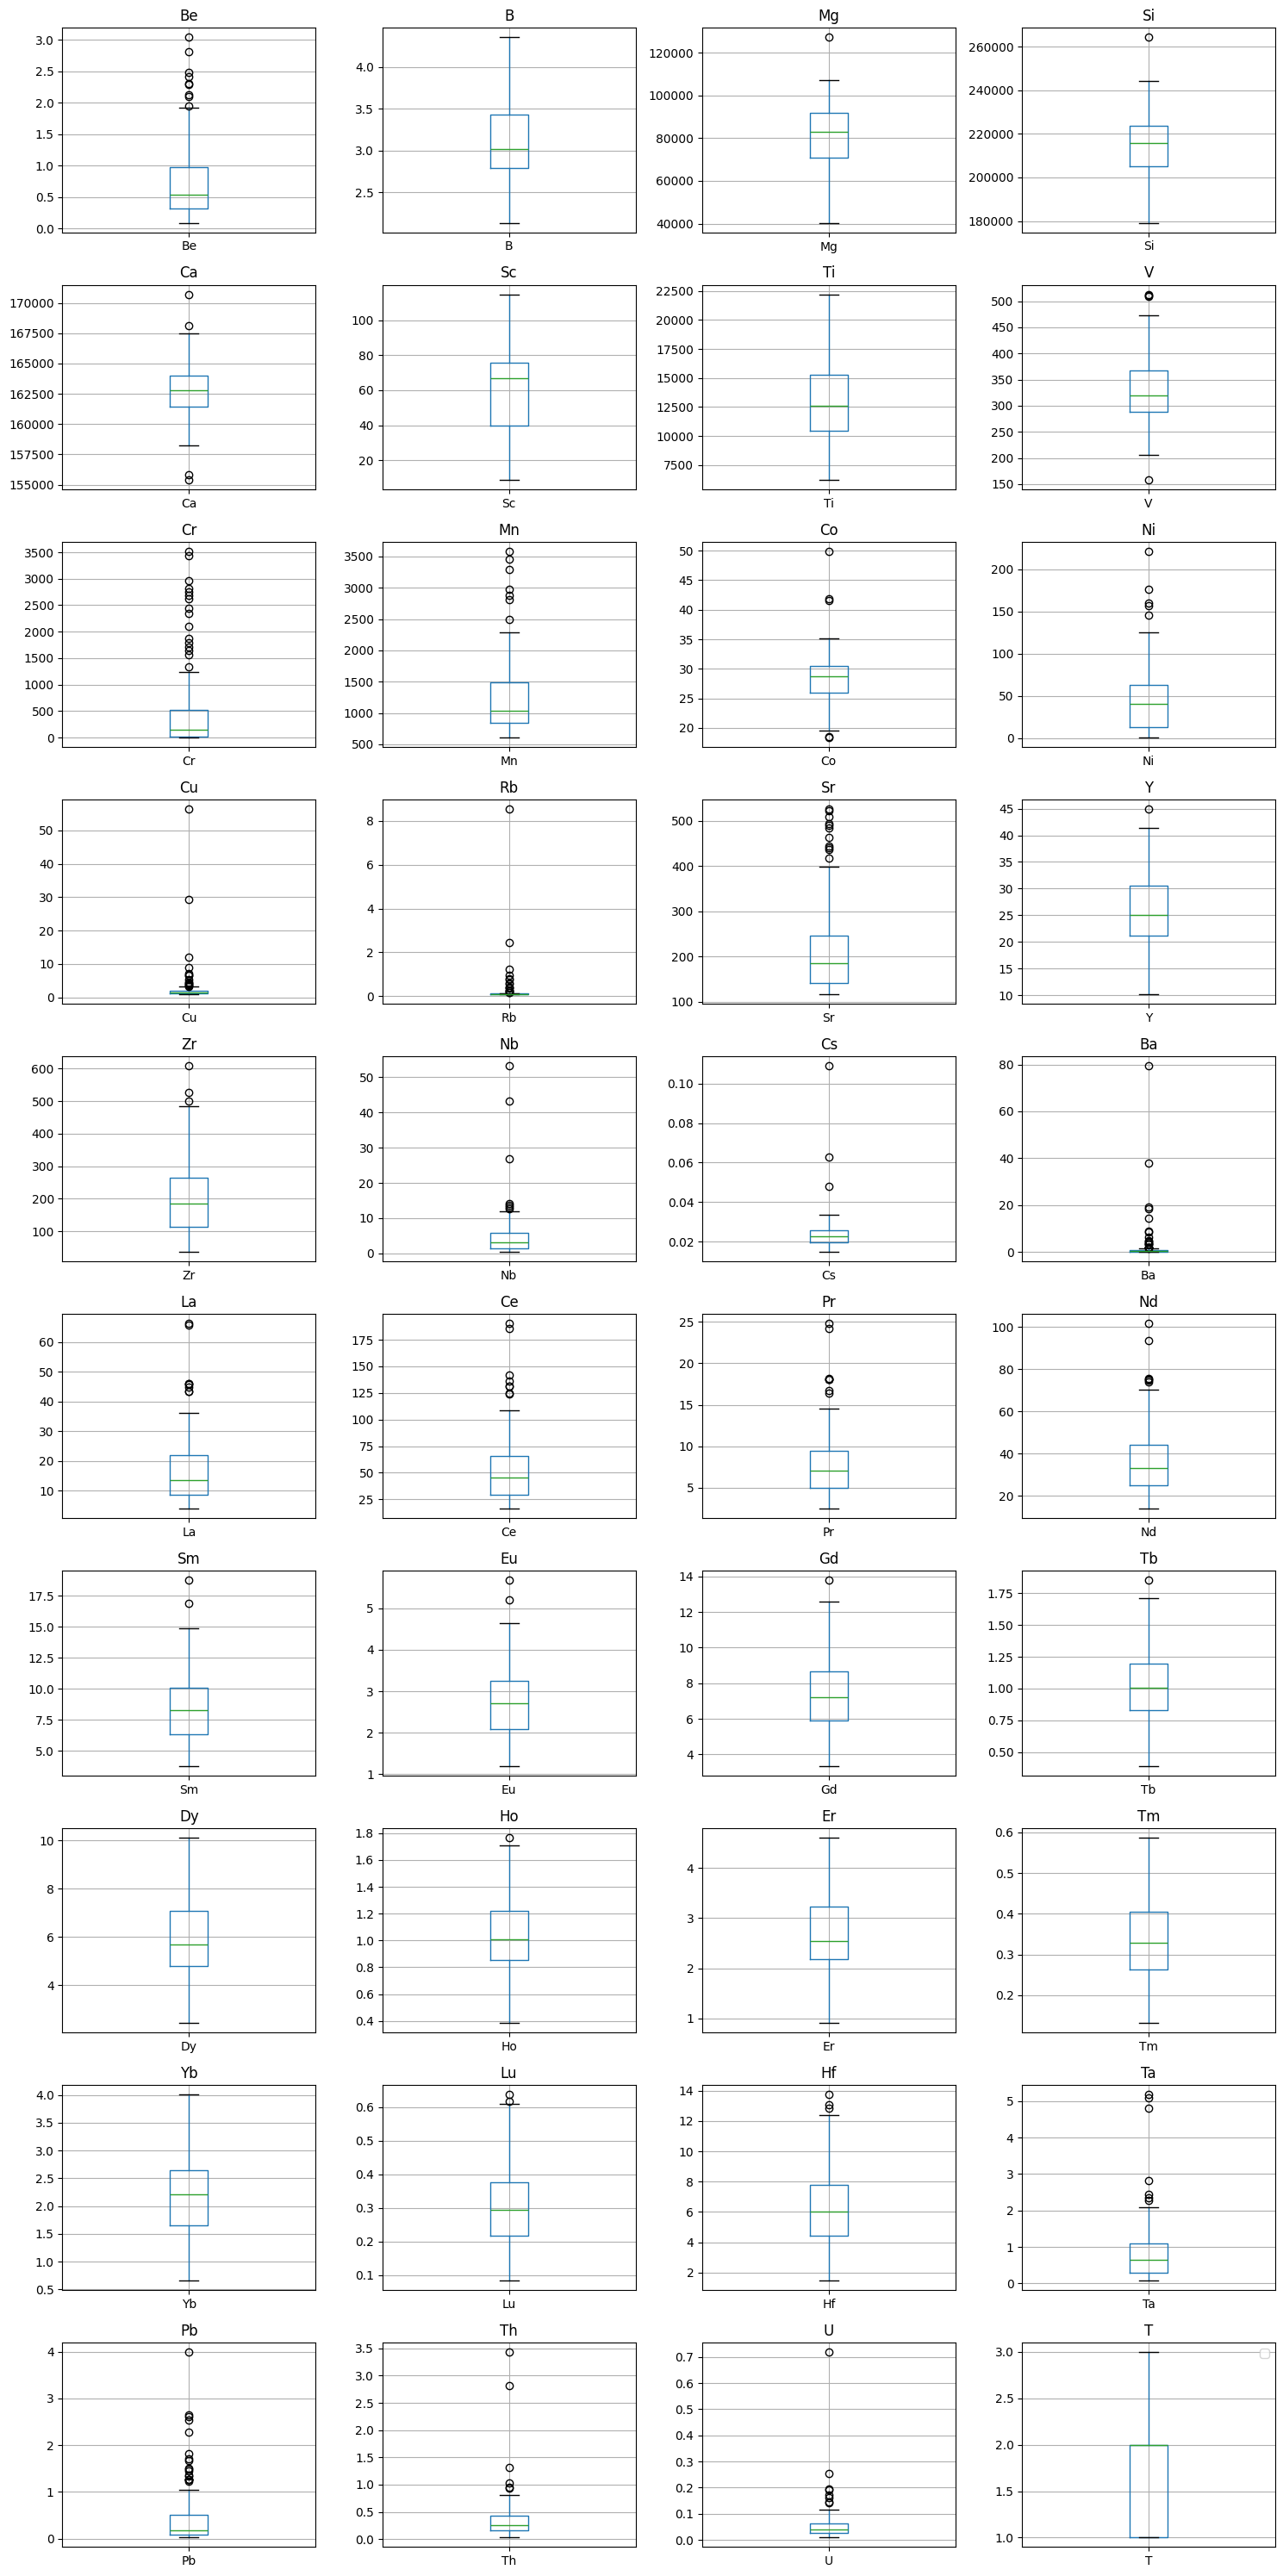

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'dataframe' is your dataframe with 40 numerical columns
numerical_columns = laicpms_with_age.select_dtypes(include=['number']).columns

# Set up subplots (e.g., 8 rows x 5 columns for 40 plots)
rows, cols = 10, 4
fig, axes = plt.subplots(rows, cols, figsize=(15, 30))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop through each column and create a boxplot
for i, column in enumerate(numerical_columns):
    if i < len(axes):  # Ensure we don't exceed the number of axes available
        laicpms_with_age.boxplot(column=column, ax=axes[i])
        axes[i].set_title(column)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the plot
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Highlight the outliers programmatically
outlier_data = {}
for col in numerical_columns:
    Q1 = laicpms_with_age[col].quantile(0.25)
    Q3 = laicpms_with_age[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = laicpms_with_age[(laicpms_with_age[col] < lower_bound) | (laicpms_with_age[col] > upper_bound)]
    outlier_data[col] = outliers

# To analyze further, 'outlier_data' contains rows with outliers for each column


In [ ]:
outlier_data

{'Be':                 SAMPLE    Be     B        Mg         Si         Ca     Sc  \
 163   KL2023-07-23-7_1  2.30  4.32  60380.18  223708.23  159988.14  57.10   
 217  KL2023-07-23-8_23  1.94  3.52  44013.43  204392.86  163406.84  13.59   
 237   KL2023-07-25-1_4  2.81  3.72  45598.86  191709.64  160865.63  16.57   
 238   KL2023-07-25-1_5  3.04  3.66  47391.17  193985.39  163475.09  14.56   
 258  KL2023-07-25-1_25  2.13  3.56  44284.92  185378.58  164386.38   8.77   
 351  KL2023-07-25-7_22  2.41  3.35  42391.04  198028.67  161106.42   8.69   
 352  KL2023-07-25-7_23  2.29  3.04  46679.96  199841.84  162860.81  13.86   
 357  KL2023-07-25-7_28  2.10  2.96  51279.80  211522.05  160114.80   9.94   
 390  KL2023-07-25-8_20  2.48  2.84  40927.28  187607.67  163210.42  11.56   
 
            Ti       V     Cr  ...    Er     Tm    Yb     Lu     Hf     Ta  \
 163  15295.52  332.95  48.63  ...  3.63  0.428  3.28  0.469  12.38  1.750   
 217  12599.56  275.02   1.32  ...  3.12  0.421  3.16  0

•	Is there evidence of contamination or systematic errors in certain elements (e.g., unusually high/low values)?

#**Data Integrity**

•	Are there redundant or conflicting columns, such as "Ca" and "Ca.1"? If so, are they properly documented?

•	Are all required columns present, and are their data types appropriate (e.g., float for concentrations, object for identifiers)?


In [ ]:
laicpms_with_age.dtypes

,0
SAMPLE,object
Be,float64
B,float64
Mg,float64
Si,float64
Ca,float64
Sc,float64
Ti,float64
V,float64
Cr,float64


#**Metadata and Units**

•	Are the units of measurement clear and consistent across all columns?


In [ ]:
# Identify numeric columns
numeric_columns = laicpms_with_age.select_dtypes(include=['float64']) #, 'int64'])

# Function to calculate the number of decimal places
def decimal_places(value):
    try:
        # Convert to string, split at decimal, and get length of fractional part
        return len(str(value).split(".")[1])
    except (IndexError, ValueError):
        return 0

# Check significant figures consistency
decimal_consistency = numeric_columns.applymap(decimal_places).nunique()

# Display results
decimal_consistency


<ipython-input-17-8d9900eb2137>:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  decimal_consistency = numeric_columns.applymap(decimal_places).nunique()


,0
Be,4
B,3
Mg,3
Si,3
Ca,3
Sc,3
Ti,3
V,3
Cr,3
Mn,3


<ipython-input-18-0ac5001f0a56>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=consistency_data.index, y=consistency_data.values, palette="viridis")


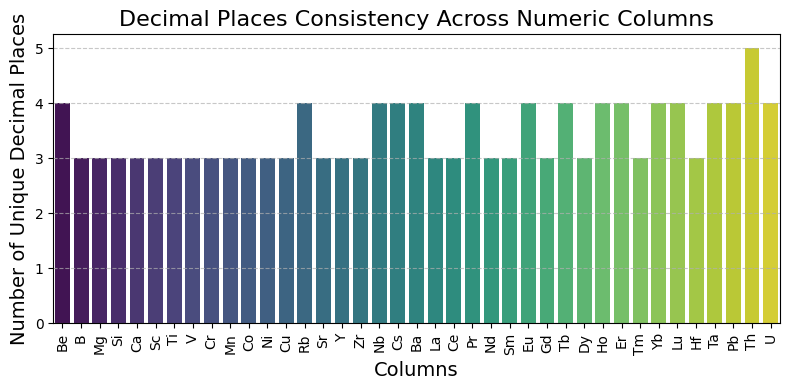

In [ ]:
# Create a colorful bar chart to visualize the decimal places consistency
def plot_decimal_consistency(consistency_data):
    plt.figure(figsize=(8, 4))
    sns.barplot(x=consistency_data.index, y=consistency_data.values, palette="viridis")
    plt.title("Decimal Places Consistency Across Numeric Columns", fontsize=16)
    plt.xlabel("Columns", fontsize=14)
    plt.ylabel("Number of Unique Decimal Places", fontsize=14)
    plt.xticks(rotation=90, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call the function to visualize the results
plot_decimal_consistency(decimal_consistency)

**Quality Control and Replicates**

•	Are there any replicates, and if so, do they show consistent results?


In [ ]:
# Check for granularity in the data by looking at unique counts for each column
granularity_analysis = laicpms_with_age.nunique()

# Check for measurement precision by analyzing the numeric columns

# Calculate the number of unique values for each numeric column to assess precision
numeric_columns = laicpms_with_age.select_dtypes(include=['float64', 'int64'])
precision_analysis = numeric_columns.apply(lambda col: col.nunique())

# Present the results to the user
print("Granularity Analysis in Sheet: epma",granularity_analysis)

print("Measurement Precision Analysis in Sheet: epma",precision_analysis)

Granularity Analysis in Sheet: epma SAMPLE    388
Be         87
B          87
Mg        116
Si        116
Ca        116
Sc        114
Ti        116
V         114
Cr        113
Mn        116
Co        110
Ni        113
Cu         93
Rb         58
Sr        116
Y         113
Zr        116
Nb        114
Cs         73
Ba        107
La        115
Ce        114
Pr        111
Nd        116
Sm        106
Eu         95
Gd        109
Tb        113
Dy        108
Ho        110
Er         92
Tm        104
Yb         91
Lu        100
Hf        108
Ta        112
Pb         99
Th        105
U         105
T           3
dtype: int64
Measurement Precision Analysis in Sheet: epma Be     87
B      87
Mg    116
Si    116
Ca    116
Sc    114
Ti    116
V     114
Cr    113
Mn    116
Co    110
Ni    113
Cu     93
Rb     58
Sr    116
Y     113
Zr    116
Nb    114
Cs     73
Ba    107
La    115
Ce    114
Pr    111
Nd    116
Sm    106
Eu     95
Gd    109
Tb    113
Dy    108
Ho    110
Er     92
Tm    104
Yb     91
L

<ipython-input-20-8f8f5b572411>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="viridis")


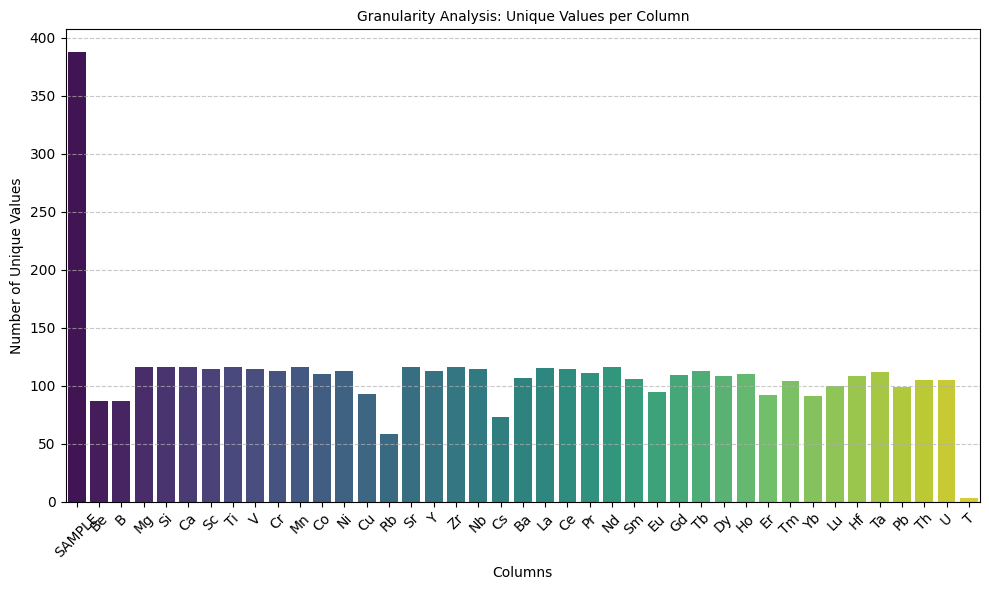

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



# Visualization for Granularity Analysis
def plot_granularity(data):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=data.index, y=data.values, palette="viridis")
    plt.title("Granularity Analysis: Unique Values per Column", fontsize=10)
    plt.xlabel("Columns", fontsize=10)
    plt.ylabel("Number of Unique Values", fontsize=10)
    plt.xticks(rotation=45, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



# Call the functions to visualize the results
plot_granularity(granularity_analysis)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'laicpms_with_age' is your dataframe
# Exclude 'SAMPLE' and 'T' columns
elements = [col for col in laicpms_with_age.columns if col not in ['SAMPLE', 'T']]

# 1. Group and Compare
group_summary = laicpms_with_age.groupby('SAMPLE')[elements].mean()

# Print summary statistics
print("Group Summary Statistics:")
print(group_summary)

group_summary

Group Summary Statistics:
                     Be     B        Mg         Si         Ca     Sc  \
SAMPLE                                                                 
KL2023-07-19-4_1   0.31  2.87  89280.11  220070.69  161599.52  94.13   
KL2023-07-19-4_10   NaN   NaN       NaN        NaN        NaN    NaN   
KL2023-07-19-4_11   NaN   NaN       NaN        NaN        NaN    NaN   
KL2023-07-19-4_12   NaN   NaN       NaN        NaN        NaN    NaN   
KL2023-07-19-4_13   NaN   NaN       NaN        NaN        NaN    NaN   
...                 ...   ...       ...        ...        ...    ...   
KL2023-07-25-8_5    NaN   NaN       NaN        NaN        NaN    NaN   
KL2023-07-25-8_6    NaN   NaN       NaN        NaN        NaN    NaN   
KL2023-07-25-8_7   1.66  3.01  51920.98  191930.59  161945.52  12.32   
KL2023-07-25-8_8   0.99  2.83  55718.75  194892.05  163866.06  20.54   
KL2023-07-25-8_9   0.34  3.08  71686.25  190202.61  162135.72  73.09   

                         Ti       V  

,Be,B,Mg,Si,Ca,Sc,Ti,V,Cr,Mn,...,Ho,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U
SAMPLE,,,,,,,,,,,,,,,,,,,,,
KL2023-07-19-4_1,0.31,2.87,89280.11,220070.69,161599.52,94.13,12726.38,361.77,1795.78,788.33,...,0.839,2.26,0.261,1.51,0.188,3.74,0.208,0.038,0.096,0.0176
KL2023-07-19-4_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KL2023-07-19-4_11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KL2023-07-19-4_12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KL2023-07-19-4_13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KL2023-07-25-8_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KL2023-07-25-8_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KL2023-07-25-8_7,1.66,3.01,51920.98,191930.59,161945.52,12.32,13043.88,265.83,1.31,1738.69,...,1.210,3.29,0.451,2.91,0.449,10.83,1.889,0.179,0.427,0.0467
